In [32]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [63]:
def PlotPS_Timeseries(lat, lon, **kwargs):
    fig, ax = plt.subplots()

    for k, val in kwargs.items():
        ax.plot(val[0],
                val[1].PS.sel(lat=lat, lon=lon) - 100000,
                label=k,
                linestyle=val[2]
                )

    ax.set_ylabel("PS - 1000000 [Pa]")
    ax.set_xlabel("Time [minutes]")
    ax.set_title(f"Lat={lat}, lon={lon}")
    ax.legend()

In [27]:
SCRATCH_NF = "/glade/derecho/scratch/nforcone"

# nonhydrostatic
SENH_DIR = "work.StormSPEED_FADIAB_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_nonhydro/run"
SENH_FILE = "work.StormSPEED_FADIAB_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_nonhydro.cam.h0i.0001-01-01-00000.nc"
SENH_PATH = os.path.join(SCRATCH_NF, SENH_DIR, SENH_FILE)
senh = xr.open_dataset(SENH_PATH).convert_calendar("standard")

# hydrostatic
SE_DIR = "/glade/derecho/scratch/nforcone/CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb/run"
SE_FILE = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb.cam.h0i.0001-01-01-00000.nc"
SE_PATH = os.path.join(SCRATCH_NF, SE_DIR, SE_FILE)
se = xr.open_dataset(SE_PATH).convert_calendar("standard")

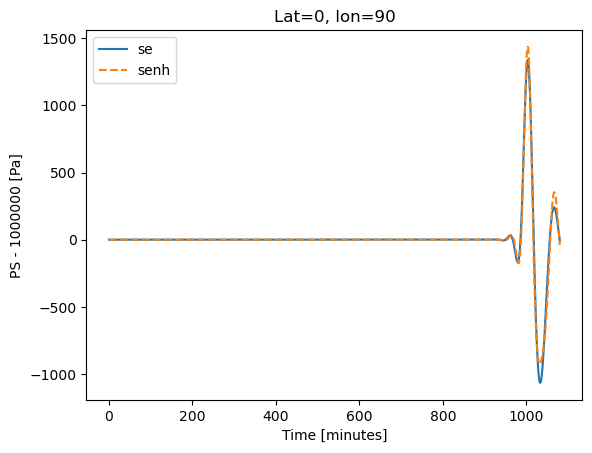

In [64]:
lat = 0
lon = 90
senh_times = np.arange(0, 1081, 2)
se_times = np.arange(0, 1081, 1)

PlotPS_Timeseries(lat, lon, se=(se_times, se, 'solid'), senh=(senh_times, senh, 'dashed'))